# One-Layer Linear Self-Attention vs One-Step Gradient Descent

This notebook reproduces the linear self-attention experiment from  **“Transformers Learn In-Context by Gradient Descent.”**

**Goal:**

- Generate simple linear regression tasks using a random teacher weight vector.
- Train a single-layer Linear Self-Attention (LSA) model on these tasks.
- Compare the LSA model’s predictions on a query point to **one step of gradient descent** on the same task.



In [10]:
# imports and setup

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


## 1. Task Sampler

Each task is a simple linear regression problem:
$$
y = w^T x, \quad w \sim \mathcal{N}(0, I), \quad x \sim U(-1, 1)^d
$$

For each task we sample:
- **n context points** $(X, Y)$  
- **1 query input** $(x_q, y_q)$  

We use \(d = n = 10\) and scalar outputs (\(out\_dim = 1\)) similar to what we learn in the paoper

In [11]:
# 1. Task Sampler
# Each task is a simple linear regression problem with:
# - n context points (X, Y)
# - 1 query input x_q and its label y_q
# We use d = n = 10 and scalar outputs (out_dim = 1), similar to the paper.

class LinearTaskSampler:
    def __init__(self, d=10, n=10, batch_tasks=256, out_dim=1, x_range=1.0, device=device):
        self.d = d                  # input dimension
        self.n = n                  # number of context points per task
        self.B = batch_tasks        # number of tasks per batch
        self.out_dim = out_dim      # number of outputs (1 for scalar regression)
        self.x_range = x_range
        self.device = device

    def sample_batch(self):
        # teacher weights: [B, 1, d]
        W_true = torch.randn(self.B, self.out_dim, self.d, device=self.device)

        # context inputs: [B, n, d]
        X = (2 * self.x_range) * torch.rand(self.B, self.n, self.d, device=self.device) - self.x_range
        # context targets: [B, n, 1] = X @ W^T
        Y = torch.matmul(X, W_true.transpose(1, 2))

        # query input: [B, d]
        x_q = (2 * self.x_range) * torch.rand(self.B, self.d, device=self.device) - self.x_range
        # query target: [B, 1]
        y_q = torch.matmul(x_q.unsqueeze(1), W_true.transpose(1, 2)).squeeze(1)

        return X, Y, x_q, y_q, W_true


task_sampler = LinearTaskSampler()
X, Y, x_q, y_q, W_true = task_sampler.sample_batch()
print("X shape:", X.shape, "Y shape:", Y.shape, "x_q shape:", x_q.shape, "y_q shape:", y_q.shape)

X shape: torch.Size([256, 10, 10]) Y shape: torch.Size([256, 10, 1]) x_q shape: torch.Size([256, 10]) y_q shape: torch.Size([256, 1])


## 2. One-Layer Linear Self-Attention Model

We implement a single-head LSA layer:

For each token sequence \([x_i, y_i]\), we compute:

$$
Q = W_Q \cdot \text{tokens}, \quad
K = W_K \cdot \text{tokens}, \quad
V = W_V \cdot \text{tokens}
$$

and the attention aggregation:

$$
\text{attn\_output} = K^T Q \, V
$$

There is **no softmax normalization**, which makes this a *linear* attention mechanism


So the updated tokens are:

$$
\text{tokens}' = \text{tokens} + P(\text{attn\_output})
$$

This model can learn to perform a one gd internally

In [12]:
# 2. One-Layer Linear Self-Attention Model
# Single-head linear self-attention without softmax.
# The layer updates tokens via:
#   tokens' = tokens + P( K(tokens)ᵀ Q(tokens) V(tokens) )

class LinearSelfAttention1L(nn.Module):

    def __init__(self, token_dim: int):
        super().__init__()
        D = token_dim
        self.W_Q = nn.Linear(D, D, bias=False)
        self.W_K = nn.Linear(D, D, bias=False)
        self.W_V = nn.Linear(D, D, bias=False)
        self.P   = nn.Linear(D, D, bias=False)

    def forward(self, tokens: torch.Tensor) -> torch.Tensor:

        Q = self.W_Q(tokens)  # [B, T, D]
        K = self.W_K(tokens)  # [B, T, D]
        V = self.W_V(tokens)  # [B, T, D]

        att_logits = torch.einsum("bid,bjd->bij", K, Q)  # [B, T, T]
        att_values = torch.einsum("bij,bjd->bid", att_logits, V)  # [B, T, D]
        updated_tokens = tokens + self.P(att_values)
        return updated_tokens


d = 10
out_dim = 1
token_dim = d + out_dim
lsa_model = LinearSelfAttention1L(token_dim=token_dim).to(device)
print(lsa_model)


LinearSelfAttention1L(
  (W_Q): Linear(in_features=11, out_features=11, bias=False)
  (W_K): Linear(in_features=11, out_features=11, bias=False)
  (W_V): Linear(in_features=11, out_features=11, bias=False)
  (P): Linear(in_features=11, out_features=11, bias=False)
)


## 3. Token Construction and Readout

To prepare inputs for the lsa model:

1. Convert the sampled data into **tokens**:  
   - Context tokens: `[x_i, y_i]` for each example in the support set
   - Query token: `[x_q, 0]`, where the target is initially masked to zero

2. Pass all tokens through the **LSA layer**, which processes context–query relationships within a single attention pass

3. Extract the final pred from the query token


In [13]:
def build_tokens(X, Y, x_q, y_q_init=None):
    """
    Build token sequence for LSA model.

    Context tokens: [x_i, y_i] for each context point.
    Query token:    [x_q, y_q_init], where y_q_init is usually 0.

    Returns:
        tokens: [B, n_context + 1, d + out_dim]
    """
    B, n, d = X.shape
    out_dim = Y.shape[-1]
    if y_q_init is None:
        y_q_init = torch.zeros(B, out_dim, device=X.device)

    # context tokens: [x, y]
    ctx_tokens = torch.cat([X, Y], dim=-1)                      

    # query token: [x_q, y_q_init]
    query_token = torch.cat([x_q, y_q_init], dim=-1).unsqueeze(1) 

    # concat along time dimension (context + query)
    tokens = torch.cat([ctx_tokens, query_token], dim=1) 
    return tokens


def readout_query_prediction(updated_tokens, out_dim=1):
    """
    Read out predicted y for the query token.

    Assumes:
    - query token is the **last** token in the sequence
    - y-slot is stored in the last `out_dim` entries of the token
    """
    return updated_tokens[:, -1, -out_dim:]


## 4. One-Step Gradient Descent Baseline

To compare against explicit optimization, we compute **one step of gradient descent** for a linear model starting from \(w_0 = 0\):

$$
\Delta w = \frac{\eta}{N} \sum_i y_i x_i
\quad \text{and} \quad
\hat{y}_{GD} = (\Delta w)^T x_q
$$



In [14]:
def gd_one_step_pred(X, Y, x_q, lr: float):
    """
    Compute a one-step gradient descent prediction for linear regression.

    We start from w_0 = 0 and take one gradient step on the squared loss
    using the context points (X, Y), then evaluate at x_q.
    """
    B, n, d = X.shape

    # Σ_i y_i * x_i -> [B, d]
    sum_yx = (X * Y).sum(dim=1)

    # Δw: [B, d]
    delta_w = (lr / n) * sum_yx

    # query prediction: <Δw, x_q> -> [B, 1]
    y_hat_gd = (delta_w * x_q).sum(dim=-1, keepdim=True)
    return y_hat_gd

## 5. Training Loop: LSA vs One-Step GD

During training, lsa is compared to a one-stepgd  baseline on synthetic linear regression tasks

At each iteration:

1. **Sample a batch of tasks** 
2. **Build tokens** 
3. **Run the LSA model** 
4. **Compute the GD baseline** 
5. **Train the LSA model** 
6. **Record both LSA and GD losses** 



In [15]:
# training hyperparameters
num_steps        = 2000
batch_tasks      = 256
d                = 10
n_context        = 10
out_dim          = 1
x_range          = 1.0

lsa_lr           = 1e-3   # optimizer LR for LSA params
gd_lr            = 0.5    # learning rate used in one-step GD baseline
print_every      = 100


task_sampler = LinearTaskSampler(
    d=d, n=n_context, batch_tasks=batch_tasks, out_dim=out_dim, x_range=x_range, device=device
)
token_dim = d + out_dim
lsa_model = LinearSelfAttention1L(token_dim=token_dim).to(device)
optimizer = torch.optim.Adam(lsa_model.parameters(), lr=lsa_lr)

lsa_losses = []
gd_losses  = []
for step in range(1, num_steps + 1):
    # sample a batch of tasks
    X, Y, x_q, y_q, W_true = task_sampler.sample_batch()
    X, Y, x_q, y_q = X.to(device), Y.to(device), x_q.to(device), y_q.to(device)

    # build tokens and run LSA
    tokens = build_tokens(X, Y, x_q)                    
    updated_tokens = lsa_model(tokens)                
    y_pred_lsa = readout_query_prediction(updated_tokens, out_dim=out_dim) 

    # one-step GD baseline (no grad)
    with torch.no_grad():
        y_pred_gd = gd_one_step_pred(X, Y, x_q, lr=gd_lr)  

    # compute losses
    loss_lsa = F.mse_loss(y_pred_lsa, y_q)
    loss_gd  = F.mse_loss(y_pred_gd,  y_q)

    # update LSA model
    optimizer.zero_grad()
    loss_lsa.backward()
    optimizer.step()

    lsa_losses.append(loss_lsa.item())
    gd_losses.append(loss_gd.item())

    if step % print_every == 0:
        avg_lsa = sum(lsa_losses[-print_every:]) / print_every
        avg_gd  = sum(gd_losses[-print_every:]) / print_every
        print(f"Step {step:4d} | LSA loss: {avg_lsa:.4f} | GD loss (baseline): {avg_gd:.4f}")

Step  100 | LSA loss: 3.2808 | GD loss (baseline): 2.4066
Step  200 | LSA loss: 2.7169 | GD loss (baseline): 2.3900
Step  300 | LSA loss: 2.1709 | GD loss (baseline): 2.3977
Step  400 | LSA loss: 1.9488 | GD loss (baseline): 2.4317
Step  500 | LSA loss: 1.8855 | GD loss (baseline): 2.4214
Step  600 | LSA loss: 1.7776 | GD loss (baseline): 2.4305
Step  700 | LSA loss: 1.7242 | GD loss (baseline): 2.4065
Step  800 | LSA loss: 1.6578 | GD loss (baseline): 2.3667
Step  900 | LSA loss: 1.6557 | GD loss (baseline): 2.4237
Step 1000 | LSA loss: 1.6867 | GD loss (baseline): 2.4153
Step 1100 | LSA loss: 1.6538 | GD loss (baseline): 2.3972
Step 1200 | LSA loss: 1.6453 | GD loss (baseline): 2.3725
Step 1300 | LSA loss: 1.6543 | GD loss (baseline): 2.3907
Step 1400 | LSA loss: 1.6654 | GD loss (baseline): 2.3912
Step 1500 | LSA loss: 1.6442 | GD loss (baseline): 2.3859
Step 1600 | LSA loss: 1.6682 | GD loss (baseline): 2.4089
Step 1700 | LSA loss: 1.6745 | GD loss (baseline): 2.4025
Step 1800 | LS

## 6. Plotting LSA Loss vs GD Loss

We visualize the loss curves for both models during training:

- **Raw losses:** show per-step mean squared error (MSE) for each batch.  
- **Smoothed losses:** show moving averages to highlight overall trends.  


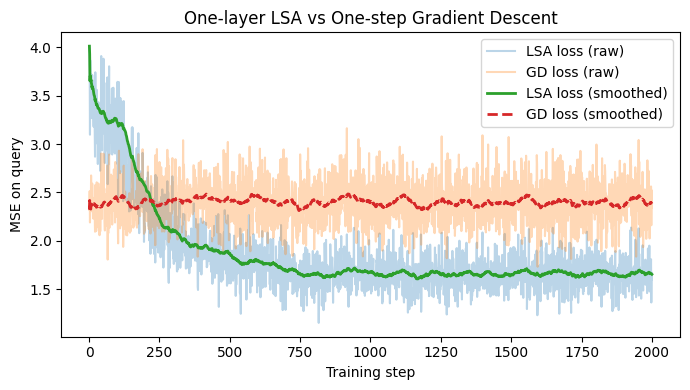

In [16]:
def moving_average(xs, window=50):
    """
    Simple moving average over a 1D Python list.
    Used to smooth loss curves for visualization.
    """
    if len(xs) < window:
        return xs
    out = []
    for i in range(len(xs)):
        start = max(0, i - window + 1)
        out.append(sum(xs[start:i+1]) / (i - start + 1))
    return out


steps = list(range(1, num_steps + 1))
lsa_ma = moving_average(lsa_losses, window=50)
gd_ma  = moving_average(gd_losses,  window=50)

plt.figure(figsize=(7, 4))
plt.plot(steps, lsa_losses, alpha=0.3, label="LSA loss (raw)")
plt.plot(steps, gd_losses,  alpha=0.3, label="GD loss (raw)")
plt.plot(steps, lsa_ma, linewidth=2, label="LSA loss (smoothed)")
plt.plot(steps, gd_ma,  linewidth=2, linestyle="--", label="GD loss (smoothed)")
plt.xlabel("Training step")
plt.ylabel("MSE on query")
plt.title("One-layer LSA vs One-step Gradient Descent")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Cosine Similarity Evaluation

To further quantify similarity, we compute **cosine similarity** between the final predictions from LSA and GD:

$$
\text{cos\_sim}(a, b) = \frac{a \cdot b}{\|a\|\|b\|}
$$

A higher cosine similarity indicates that both models are producing nearly identical predictions across tasks.



In [17]:
def cosine_similarity(a, b, eps=1e-8):
    """
    Computes average cosine similarity between two prediction tensors.

    Args:
        a, b: [B, ...] tensors of predictions.
    Returns:
        scalar float: mean cosine similarity across the batch.
    """
    a_flat = a.view(a.size(0), -1)
    b_flat = b.view(b.size(0), -1)
    dot = (a_flat * b_flat).sum(dim=-1)
    norm_a = a_flat.norm(dim=-1) + eps
    norm_b = b_flat.norm(dim=-1) + eps
    cos = dot / (norm_a * norm_b)
    return cos.mean().item()


# evaluate cosine similarity on a fresh batch
X_eval, Y_eval, x_q_eval, y_q_eval, W_true_eval = task_sampler.sample_batch()
with torch.no_grad():
    tokens_eval = build_tokens(X_eval.to(device), Y_eval.to(device), x_q_eval.to(device))
    updated_tokens_eval = lsa_model(tokens_eval)
    y_pred_lsa_eval = readout_query_prediction(updated_tokens_eval, out_dim=out_dim)
    y_pred_gd_eval  = gd_one_step_pred(X_eval.to(device), Y_eval.to(device), x_q_eval.to(device), lr=gd_lr)

cos_sim = cosine_similarity(y_pred_lsa_eval, y_pred_gd_eval)
print(f"Cosine similarity between LSA predictions and GD predictions: {cos_sim:.4f}")


Cosine similarity between LSA predictions and GD predictions: 0.9375


In [18]:
#close to 1 ^ hence proving our conclusion

## Summary

- We trained a **one-layer linear self-attention (LSA)** model on simple linear regression tasks.
- The model learns to map context tokens `[x_i, y_i]` and a query token `[x_q, 0]` to a good prediction for the query label.
- We compared the LSA predictions to an explicit **one-step gradient descent** baseline on the same tasks.
- Loss curves and cosine similarity show that the LSA model’s predictions closely track the one-step GD predictions across tasks.
